In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("startup_funding.csv")


In [ ]:
df.head()

df.info()

df.describe()

df.isnull().sum()

df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3044 entries, 0 to 3043
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Sr No              3044 non-null   int64 
 1   Date dd/mm/yyyy    3044 non-null   object
 2   Startup Name       3044 non-null   object
 3   Industry Vertical  2873 non-null   object
 4   SubVertical        2108 non-null   object
 5   City  Location     2864 non-null   object
 6   Investors Name     3020 non-null   object
 7   InvestmentnType    3040 non-null   object
 8   Amount in USD      2084 non-null   object
 9   Remarks            419 non-null    object
dtypes: int64(1), object(9)
memory usage: 237.9+ KB


np.int64(0)

In [ ]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
len(df)

3044

In [ ]:
df['Amount in USD'] = df['Amount in USD'].astype(str).str.replace(',', '').str.replace('INR', '').str.strip()
df['Amount in USD'] = pd.to_numeric(df['Amount in USD'], errors='coerce')

df['Funding_Success'] = df['Amount in USD'].notna() & (df['Amount in USD'] > 0)

success_rate = df["Funding_Success"].mean()*100
print(success_rate)

67.83837056504599


In [ ]:
df[['Founder_Experience',
    'Team_Size',
    'Startup_Age']].mean()

KeyError: "None of [Index(['Founder_Experience', 'Team_Size', 'Startup_Age'], dtype='object')] are in the [columns]"

In [ ]:
print(df.columns)

Index(['Sr No', 'Date dd/mm/yyyy', 'Startup Name', 'Industry Vertical',
       'SubVertical', 'City  Location', 'Investors Name', 'InvestmentnType',
       'Amount in USD', 'Remarks', 'Funding_Success'],
      dtype='object')


In [ ]:
df[['Founder_Experience',
    'Team_Size',
    'Startup_Age']].median()

KeyError: "None of [Index(['Founder_Experience', 'Team_Size', 'Startup_Age'], dtype='object')] are in the [columns]"

In [ ]:
df['Amount in USD'].describe()

,Amount in USD
count,2.065000e+03
mean,1.842990e+07
std,1.213734e+08
min,1.600000e+04
25%,4.700000e+05
50%,1.700000e+06
75%,8.000000e+06
max,3.900000e+09


In [ ]:
df[['Founder_Experience',
    'Team_Size',
    'Startup_Age']].std()

KeyError: "None of [Index(['Founder_Experience', 'Team_Size', 'Startup_Age'], dtype='object')] are in the [columns]"

In [ ]:
df.describe()

,Sr No,Amount in USD
count,3044.000000,2.065000e+03
mean,1522.500000,1.842990e+07
std,878.871435,1.213734e+08
min,1.000000,1.600000e+04
25%,761.750000,4.700000e+05
50%,1522.500000,1.700000e+06
75%,2283.250000,8.000000e+06
max,3044.000000,3.900000e+09


In [ ]:
df[['Sr No', 'Amount in USD']].quantile([0.25,0.50,0.75])

,Sr No,Amount in USD
0.25,761.75,470000.0
0.50,1522.50,1700000.0
0.75,2283.25,8000000.0


In [ ]:
np.percentile(df['Amount in USD'].dropna(), [10,25,50,75,90])

array([  155400.        ,   470000.        ,  1700000.        ,
        8000000.        , 28600000.00000014])

In [ ]:
df.groupby('Funding_Success')['Amount in USD'].mean()

,Amount in USD
Funding_Success,
False,NaN
True,1.842990e+07


In [ ]:
p_funding = len(df[df['Funding_Success']==1]) / len(df)

In [ ]:
ai = df[df['Industry Vertical']=="AI"]
p_ai = len(ai[ai['Funding_Success']==1]) / len(ai)

In [ ]:
experienced = df[df['Founder_Experience']>5]

p_exp = len(experienced[
    experienced['Funding_Success']==1
]) / len(experienced)

KeyError: 'Founder_Experience'

In [ ]:
df.head()

,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks,Funding_Success
0,1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,200000000.0,NaN,True
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,8048394.0,NaN,True
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,18358860.0,NaN,True
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,3000000.0,NaN,True
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,1800000.0,NaN,True


In [ ]:
city_prob = df.groupby('City  Location')[
    'Funding_Success'
].mean()*100

In [ ]:
df['Growth_Category'] = pd.cut(
    df['Growth_Rate'],
    bins=[0,20,50,100,500],
    labels=['Low','Medium','High','Very High']
)

growth_prob = df.groupby(
    'Growth_Category'
)['Funding_Success'].mean()*100

KeyError: 'Growth_Rate'

In [ ]:
df['Amount in USD'].describe()

,Amount in USD
count,2.065000e+03
mean,1.842990e+07
std,1.213734e+08
min,1.600000e+04
25%,4.700000e+05
50%,1.700000e+06
75%,8.000000e+06
max,3.900000e+09


In [ ]:
df['Growth_Category'] = pd.cut(
    df['Growth_Rate'],
    bins=[0,20,50,100,500],
    labels=['Low','Medium','High','Very High']
)

growth_prob = df.groupby(
    'Growth_Category'
)['Funding_Success'].mean()*100

KeyError: 'Growth_Rate'

In [ ]:
df.head()

,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks,Funding_Success
0,1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,200000000.0,NaN,True
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,8048394.0,NaN,True
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,18358860.0,NaN,True
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,3000000.0,NaN,True
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,1800000.0,NaN,True


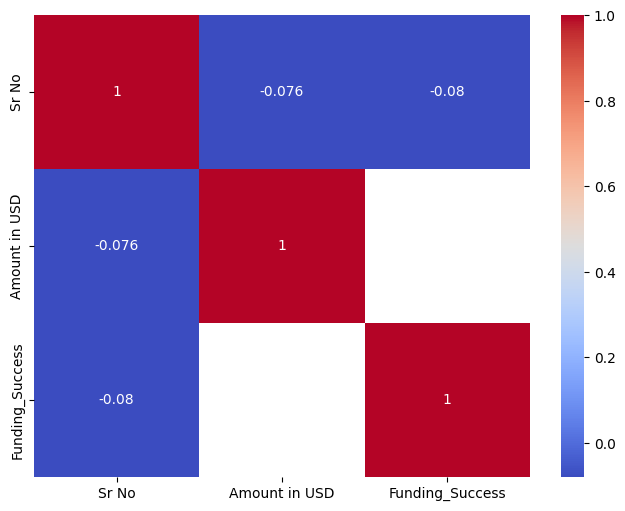

In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')
plt.show()

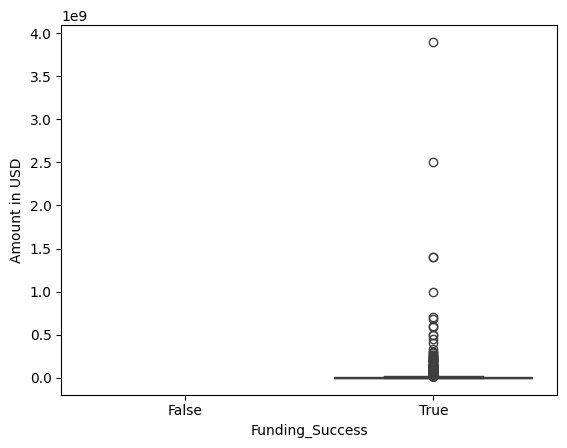

In [ ]:
sns.boxplot(
    x='Funding_Success',
    y='Amount in USD',
    data=df
)
plt.show()

In [ ]:
print(df.columns.tolist())

['Sr No', 'Date dd/mm/yyyy', 'Startup Name', 'Industry Vertical', 'SubVertical', 'City  Location', 'Investors Name', 'InvestmentnType', 'Amount in USD', 'Remarks', 'Funding_Success']


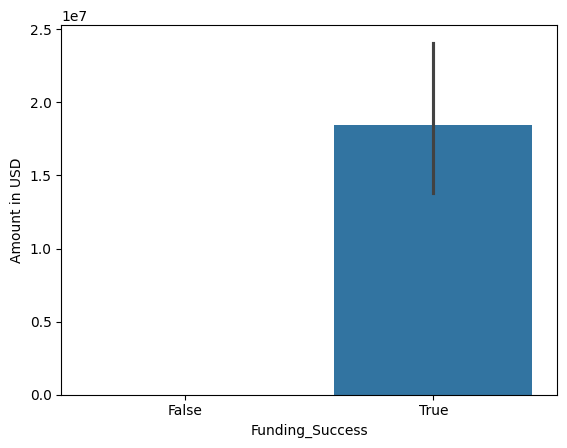

In [ ]:
sns.barplot(
    x='Funding_Success',
    y='Amount in USD',
    data=df
)
plt.show()

In [ ]:
sns.scatterplot(
    x='Revenue',
    y='Growth_Rate',
    hue='Funding_Success',
    data=df
)
plt.show()

ValueError: Could not interpret value `Revenue` for `x`. An entry with this name does not appear in `data`.

In [ ]:
print(df.columns.tolist())

['Sr No', 'Date dd/mm/yyyy', 'Startup Name', 'Industry Vertical', 'SubVertical', 'City  Location', 'Investors Name', 'InvestmentnType', 'Amount in USD', 'Remarks', 'Funding_Success']


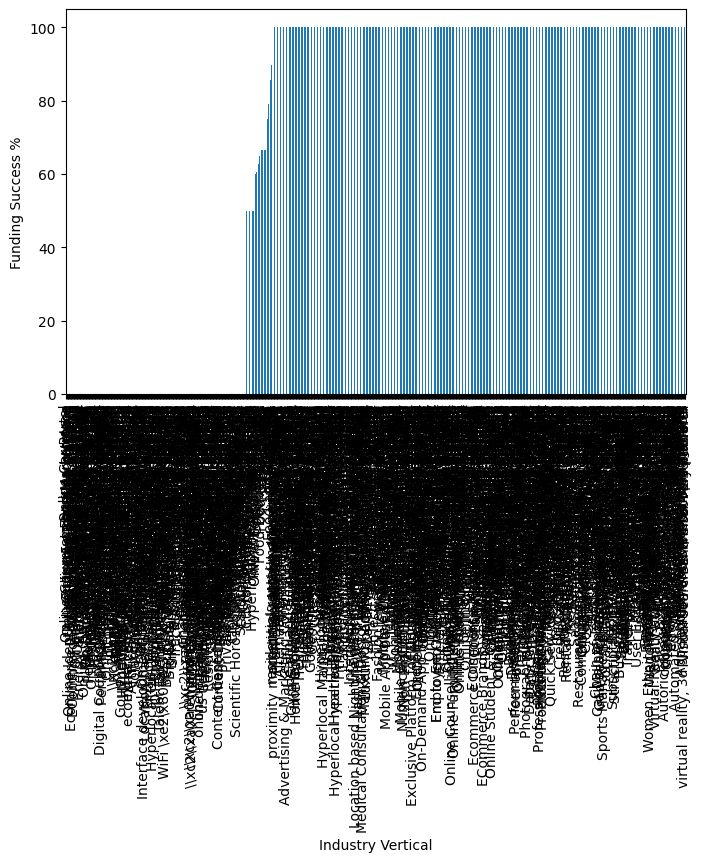

In [ ]:
industry = df.groupby(
    'Industry Vertical'
)['Funding_Success'].mean()*100

industry.sort_values().plot(
    kind='bar',
    figsize=(8,5)
)
plt.ylabel("Funding Success %")
plt.show()

In [ ]:
from scipy.stats import ttest_ind

funded = df[
    df['Funding_Success']==1
]['Founder_Experience']

not_funded = df[
    df['Funding_Success']==0
]['Founder_Experience']

t_stat, p_value = ttest_ind(
    funded,
    not_funded
)

print(p_value)

KeyError: 'Founder_Experience'

In [ ]:
correlation_amount_funding = df['Amount in USD'].corr(df['Funding_Success'].astype(int))
print(f"Correlation between 'Amount in USD' and 'Funding_Success': {correlation_amount_funding}")

Correlation between 'Amount in USD' and 'Funding_Success': nan


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [ ]:
if p_value < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")

NameError: name 'p_value' is not defined

In [ ]:
unique_investment_types = df['InvestmentnType'].unique()
print(unique_investment_types)

['Private Equity Round' 'Series C' 'Series B' 'Pre-series A' 'Seed Round'
 'Series A' 'Series D' 'Seed' 'Series F' 'Series E' 'Debt Funding'
 'Series G' 'Series H' 'Venture' 'Seed Funding' nan 'Funding Round'
 'Corporate Round' 'Maiden Round' 'pre-series A' 'Seed Funding Round'
 'Single Venture' 'Venture Round' 'Pre-Series A' 'Angel' 'Series J'
 'Angel Round' 'pre-Series A' 'Venture - Series Unknown' 'Bridge Round'
 'Private Equity' 'Debt and Preference capital' 'Inhouse Funding'
 'Seed/ Angel Funding' 'Debt' 'Pre Series A' 'Equity' 'Debt-Funding'
 'Mezzanine' 'Series B (Extension)' 'Equity Based Funding'
 'Private Funding' 'Seed / Angel Funding' 'Seed/Angel Funding'
 'Seed funding' 'Seed / Angle Funding' 'Angel / Seed Funding' 'Private'
 'Structured Debt' 'Term Loan' 'PrivateEquity' 'Angel Funding'
 'Seed\\\\nFunding' 'Private\\\\nEquity' 'Crowd funding' 'Crowd Funding']


In [ ]:
from scipy.stats import chi2_contingency

table = pd.crosstab(
    df['Industry Vertical'],
    df['Funding_Success']
)

chi2,p,dof,exp = chi2_contingency(table)

print(p)

0.2500461206408295


In [ ]:
df['Segment'] = np.where(
    df['Growth_Rate']>50,
    'High Growth',
    'Normal Growth'
)

KeyError: 'Growth_Rate'

In [ ]:
print(df.columns.tolist())

['Sr No', 'Date dd/mm/yyyy', 'Startup Name', 'Industry Vertical', 'SubVertical', 'City  Location', 'Investors Name', 'InvestmentnType', 'Amount in USD', 'Remarks', 'Funding_Success']


In [ ]:
df.loc[
    df['Founder_Experience']>5,
    'Segment'
] = 'Experienced Founder'

KeyError: 'Founder_Experience'

In [ ]:
total_funding_per_startup = df.groupby('Startup Name')['Amount in USD'].sum().reset_index()
display(total_funding_per_startup.head())

,Startup Name,Amount in USD
0,"""BYJU\\'S""",150000000.0
1,#Fame,10000000.0
2,121Policy,0.0
3,19th mile,180000.0
4,1Crowd,0.0


In [ ]:
df.loc[
    df['Revenue']>
    df['Revenue'].median(),
    'Segment'
] = 'Revenue Driven'

KeyError: 'Revenue'

In [ ]:
print(df.columns)

Index(['Sr No', 'Date dd/mm/yyyy', 'Startup Name', 'Industry Vertical',
       'SubVertical', 'City  Location', 'Investors Name', 'InvestmentnType',
       'Amount in USD', 'Remarks', 'Funding_Success'],
      dtype='object')


In [ ]:
missing_amount = df['Amount in USD'].isnull().sum()
print(f"Number of missing values in 'Amount in USD': {missing_amount}")

Number of missing values in 'Amount in USD': 979


In [ ]:
segment_success = df.groupby(
    'Segment'
)['Funding_Success'].mean()*100

KeyError: 'Segment'

In [ ]:
industry_success = df.groupby('Industry Vertical')['Funding_Success'].mean() * 100
display(industry_success.sort_values(ascending=False).head())

,Funding_Success
Industry Vertical,
visual search and discovery platform,100.0
"virtual reality, 3d simulation and stereoscopic products",100.0
3D Printer Manufacturer,100.0
mobile-only tasks marketplace,100.0
mobile social network,100.0


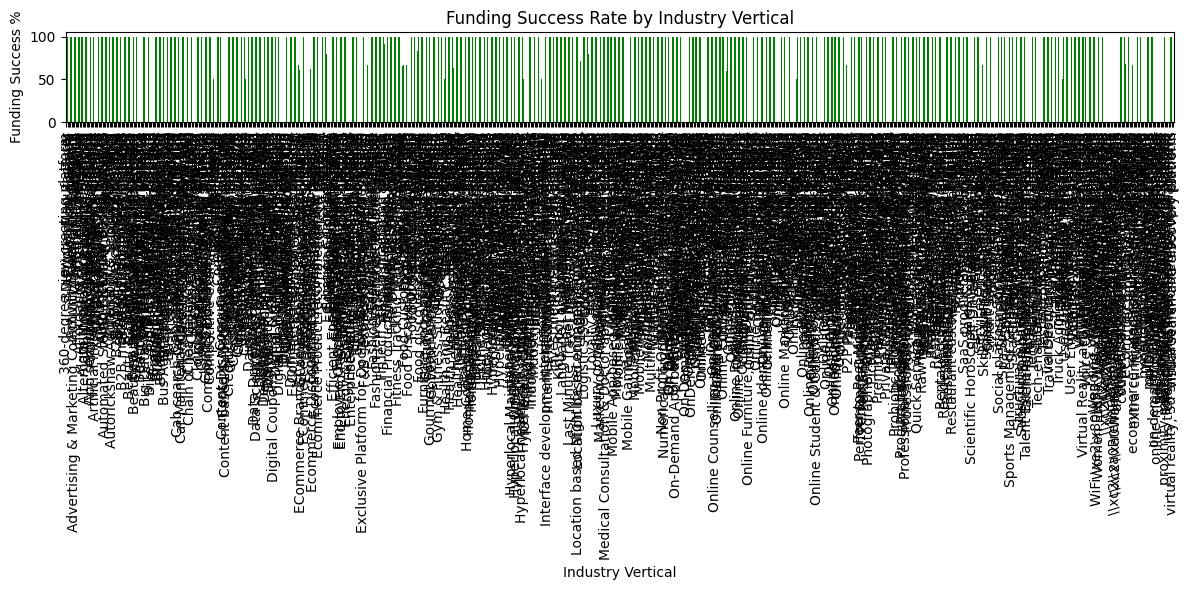

In [ ]:
industry_success.plot(
    kind='bar',
    color='green',
    figsize=(12, 6) # Added figsize for better readability
)
plt.title('Funding Success Rate by Industry Vertical') # Added title
plt.ylabel("Funding Success %")
plt.xlabel("Industry Vertical") # Added x-label
plt.xticks(rotation=90) # Rotate x-axis labels for readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()